In [1]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
# Truco para que Jupyter lea siempre la última versión de la carpeta src/
%load_ext autoreload
%autoreload 2

In [15]:
from src.data_loader import loader
from src.model_trainer import optimizar_hiperparametros_modelo
from src.evaluator import evaluar_modelo
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

import joblib
import src.config as config

In [16]:
X_train, X_test, y_train, y_test = loader(OHE=True)

print("¡Datos cargados con éxito! Tamaño de entrenamiento:", X_train.shape)

¡Datos cargados con éxito! Tamaño de entrenamiento: (95188, 58)


In [17]:
# Definir el modelo
rl_base = LogisticRegression(max_iter=500, random_state=config.RANDOM_STATE)

# Crear el espacio de búsqueda perfecto para Regresión Logística
param_grid_rl = {
    # Probar la regularización L2 (Ridge)
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10],
    # Equilibrar las pérdidas por cancelación
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear'] 
}

In [18]:
print("Buscando la mejor Regresión Logística...")

mejor_rl, hiperparametros_rl = optimizar_hiperparametros_modelo(
    rl_base, 
    param_grid_rl, 
    X_train, 
    y_train
)

print('\n¡Optimización terminada!')
print('Los mejores parámetros encontrados son:\n', hiperparametros_rl)

Buscando la mejor Regresión Logística...


c:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



¡Optimización terminada!
Los mejores parámetros encontrados son:
 {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}



	  Reporte de clasificación (Entrenamiento) - Regresión Logística Optimizada
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     59897
           1       0.72      0.76      0.74     35291

    accuracy                           0.80     95188
   macro avg       0.79      0.79      0.79     95188
weighted avg       0.80      0.80      0.80     95188


	  Reporte de clasificación (Test) - Regresión Logística Optimizada
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     14974
           1       0.72      0.77      0.74      8823

    accuracy                           0.80     23797
   macro avg       0.79      0.80      0.79     23797
weighted avg       0.81      0.80      0.80     23797



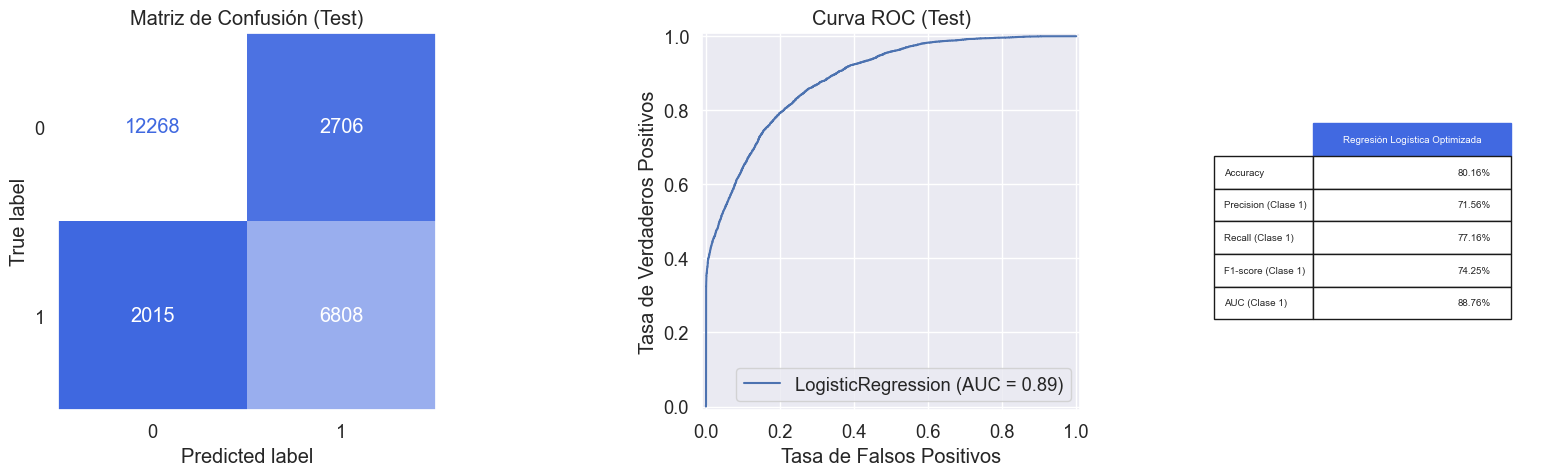

In [19]:
# Evaluación del modelo
evaluar_modelo(mejor_rl, X_train, X_test, y_train, y_test, 'Regresión Logística Optimizada')

In [20]:
joblib.dump(mejor_rl, config.RL_MODEL_PATH)
print(f"¡Modelo guardado en: {config.RL_MODEL_PATH}!")

¡Modelo guardado en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\logistic_regression.pkl!


In [5]:
dt_base = DecisionTreeClassifier(random_state=0)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

mejor_arbol, hiperparametros = optimizar_hiperparametros_modelo(dt_base, param_grid_dt, X_train, y_train)

print('¡Entrenamiento terminado! Los mejores parámetros son:\n', hiperparametros)

¡Entrenamiento terminado! Los mejores parámetros son:
 {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}



	  Reporte de clasificación (Entrenamiento) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     59897
           1       0.79      0.87      0.83     35291

    accuracy                           0.87     95188
   macro avg       0.85      0.87      0.86     95188
weighted avg       0.87      0.87      0.87     95188


	  Reporte de clasificación (Test) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     14974
           1       0.75      0.83      0.79      8823

    accuracy                           0.83     23797
   macro avg       0.82      0.83      0.83     23797
weighted avg       0.84      0.83      0.84     23797



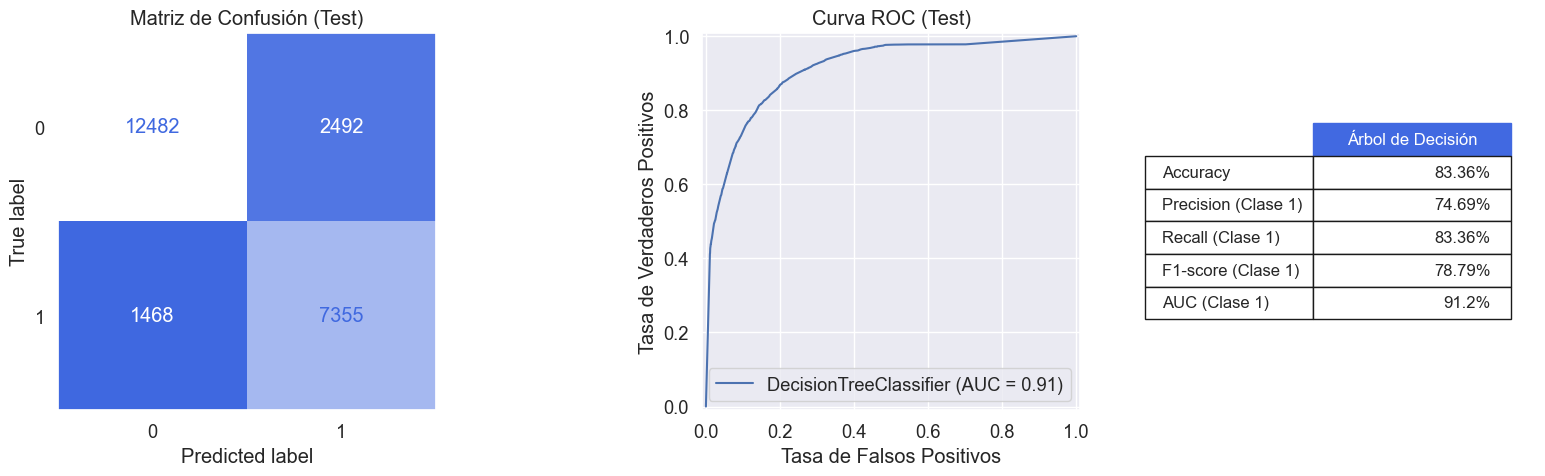

In [6]:
# Métricas de evaluación
evaluar_modelo(mejor_arbol, X_train, X_test, y_train, y_test, 'Árbol de Decisión')

In [9]:
# Guardar el modelo en un .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# 2. Guardamos nuestro árbol ganador usando la ruta de tu config.py
joblib.dump(mejor_arbol, config.DT_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.DT_MODEL_PATH}!")

¡Modelo guardado con éxito en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\tree.pkl!
